# Financial Fraud Detection using Machine Learning

## Overview & Objectives
In this notebook, we construct an end-to-end Machine Learning pipeline to detect fraudulent transactions using financial transfer data stored on Google Drive.

### Key Challenges in Fraud Detection:
* **Severe Class Imbalance:** Fraudulent transactions account for only a tiny fraction (~0.13%) of total transactions.
* **Large Dataset Volume:** Processing millions of records efficiently.

### Pipeline Steps:
1. **Drive Mounting & Data Integration:** Connecting to Google Drive and loading the dataset.
2. **Feature Engineering & Preprocessing:** Encoding categorical variables and removing irrelevant identifiers.
3. **Data Splitting:** Using Stratified Sampling to preserve fraud proportions in train/test sets.
4. **Model Training:** Training a Random Forest Classifier with balanced class weights.
5. **Model Evaluation:** Analyzing performance using Confusion Matrix, ROC-AUC, and Precision-Recall metrics.
6. **Feature Importance:** Identifying the primary drivers behind fraud detection.

In [ ]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score
)

# Set visual style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

## 1. Mount Google Drive & Load Dataset
We connect to Google Drive to locate and load the financial transactions dataset directly without manual file uploads.

In [ ]:
# Mount Google Drive
drive.mount('/content/drive')

# Search for the target CSV file across your entire Google Drive automatically
search_path = '/content/drive/MyDrive/**/PS_20174392719_1491204439457_log*.csv'
csv_files = glob.glob(search_path, recursive=True)

# Fallback: if filename was renamed, search for any CSV containing the word 'log' or 'fraud'
if not csv_files:
    csv_files = glob.glob('/content/drive/MyDrive/**/*.csv', recursive=True)
    csv_files = [f for f in csv_files if 'log' in f.lower() or 'fraud' in f.lower() or 'PS_' in f]

if not csv_files:
    raise FileNotFoundError("لم يتم العثور على الملف داخل Google Drive. تأكد من وجوده داخل MyDrive.")

file_path = csv_files[0]
print(f"Loading dataset from Drive path: {file_path}")

df = pd.read_csv(file_path)

print(f"\nDataset successfully loaded with shape: {df.shape}")
print(f"Total Transactions: {len(df):,}")
print(f"Fraudulent Transactions: {df['isFraud'].sum():,} ({df['isFraud'].mean()*100:.3f}%)")

Mounted at /content/drive
Loading dataset from Drive path: /content/drive/MyDrive/PS_20174392719_1491204439457_log.csv

Dataset successfully loaded with shape: (6362620, 11)
Total Transactions: 6,362,620
Fraudulent Transactions: 8,213 (0.129%)


## 2. Feature Engineering & Preprocessing
To prepare the dataset for machine learning models, we perform the following steps:
* **Drop Identifier Columns:** Remove unique IDs (`nameOrig`, `nameDest`) and reduntant flags (`isFlaggedFraud`) that do not aid model generalization.
* **Categorical Encoding:** Transform the transaction `type` into numerical binary columns using **One-Hot Encoding**.
* **Stratified Splitting:** Partition the dataset into **80% training** and **20% testing** sets while using stratified sampling to preserve the exact fraud ratio in both subsets.

In [ ]:
# Create a copy to prevent accidental modifications to the raw dataset
data = df.copy()

# Drop identifier columns and flagged fraud column
drop_cols = ['nameOrig', 'nameDest', 'isFlaggedFraud']
data = data.drop(columns=[col for col in drop_cols if col in data.columns])

# Apply One-Hot Encoding to categorical feature ('type')
data = pd.get_dummies(data, columns=['type'], drop_first=True)

# Separate Independent Features (X) and Target Label (y)
X = data.drop(columns=['isFraud'])
y = data['isFraud']

# Perform Stratified Train-Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Features (X) shape: {X.shape}")
print(f"Training set size: {X_train.shape[0]:,} samples")
print(f"Testing set size: {X_test.shape[0]:,} samples")

Features (X) shape: (6362620, 10)
Training set size: 5,090,096 samples
Testing set size: 1,272,524 samples


## 3. Model Training with Class Weighting
Because fraudulent activity comprises only **0.129%** of the dataset, traditional algorithms can easily achieve 99.87% accuracy by blindly predicting every transaction as non-fraudulent.

To handle this extreme class imbalance without resorting to data resampling:
* We employ a **Random Forest Classifier**.
* We set `class_weight='balanced'`, which automatically penalizes misclassifications of minority fraud samples during training.

In [ ]:
# Initialize Random Forest Classifier with balanced class weights
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

# Fit model on training data
print("Training Random Forest Model... Please wait.")
rf_model.fit(X_train, y_train)
print("Model training completed successfully!")

Training Random Forest Model... Please wait.
Model training completed successfully!


## 4. Performance Evaluation Metrics
To assess how effectively the model detects financial fraud, we calculate the following metrics on the unseen test dataset ($1.27$ million transactions):
* **Classification Report:** Detailed Breakdown of Precision, Recall, and F1-Score for both classes.
* **ROC-AUC Score:** Overall diagnostic ability of the classifier.
* **PR-AUC (Precision-Recall AUC):** The standard metric for severe class imbalance, measuring true precision across all recall thresholds.

In [ ]:
# Predict labels and probabilities on the test set
y_pred = rf_model.predict(X_test)
y_probs = rf_model.predict_proba(X_test)[:, 1]

# Display classification metrics
print("--- Classification Report ---")
print(classification_report(y_test, y_pred, digits=4))

roc_auc = roc_auc_score(y_test, y_probs)
pr_auc = average_precision_score(y_test, y_probs)

print(f"ROC-AUC Score: {roc_auc:.4f}")
print(f"PR-AUC Score:  {pr_auc:.4f}")

--- Classification Report ---
              precision    recall  f1-score   support

           0     1.0000    0.9961    0.9980   1270881
           1     0.2452    0.9696    0.3914      1643

    accuracy                         0.9961   1272524
   macro avg     0.6226    0.9829    0.6947   1272524
weighted avg     0.9990    0.9961    0.9973   1272524

ROC-AUC Score: 0.9993
PR-AUC Score:  0.9140


## 5. Visualizing Evaluation Dashboard & Feature Importance
We plot a $2 \times 2$ grid containing:
1. **Confusion Matrix:** Shows True Positives, False Positives, True Negatives, and False Negatives.
2. **ROC Curve:** Evaluates true positive vs. false positive tradeoff.
3. **Precision-Recall Curve:** Measures precision vs. sensitivity under extreme class imbalance.
4. **Top 10 Feature Importance:** Identifies key variables contributing to fraud detection.

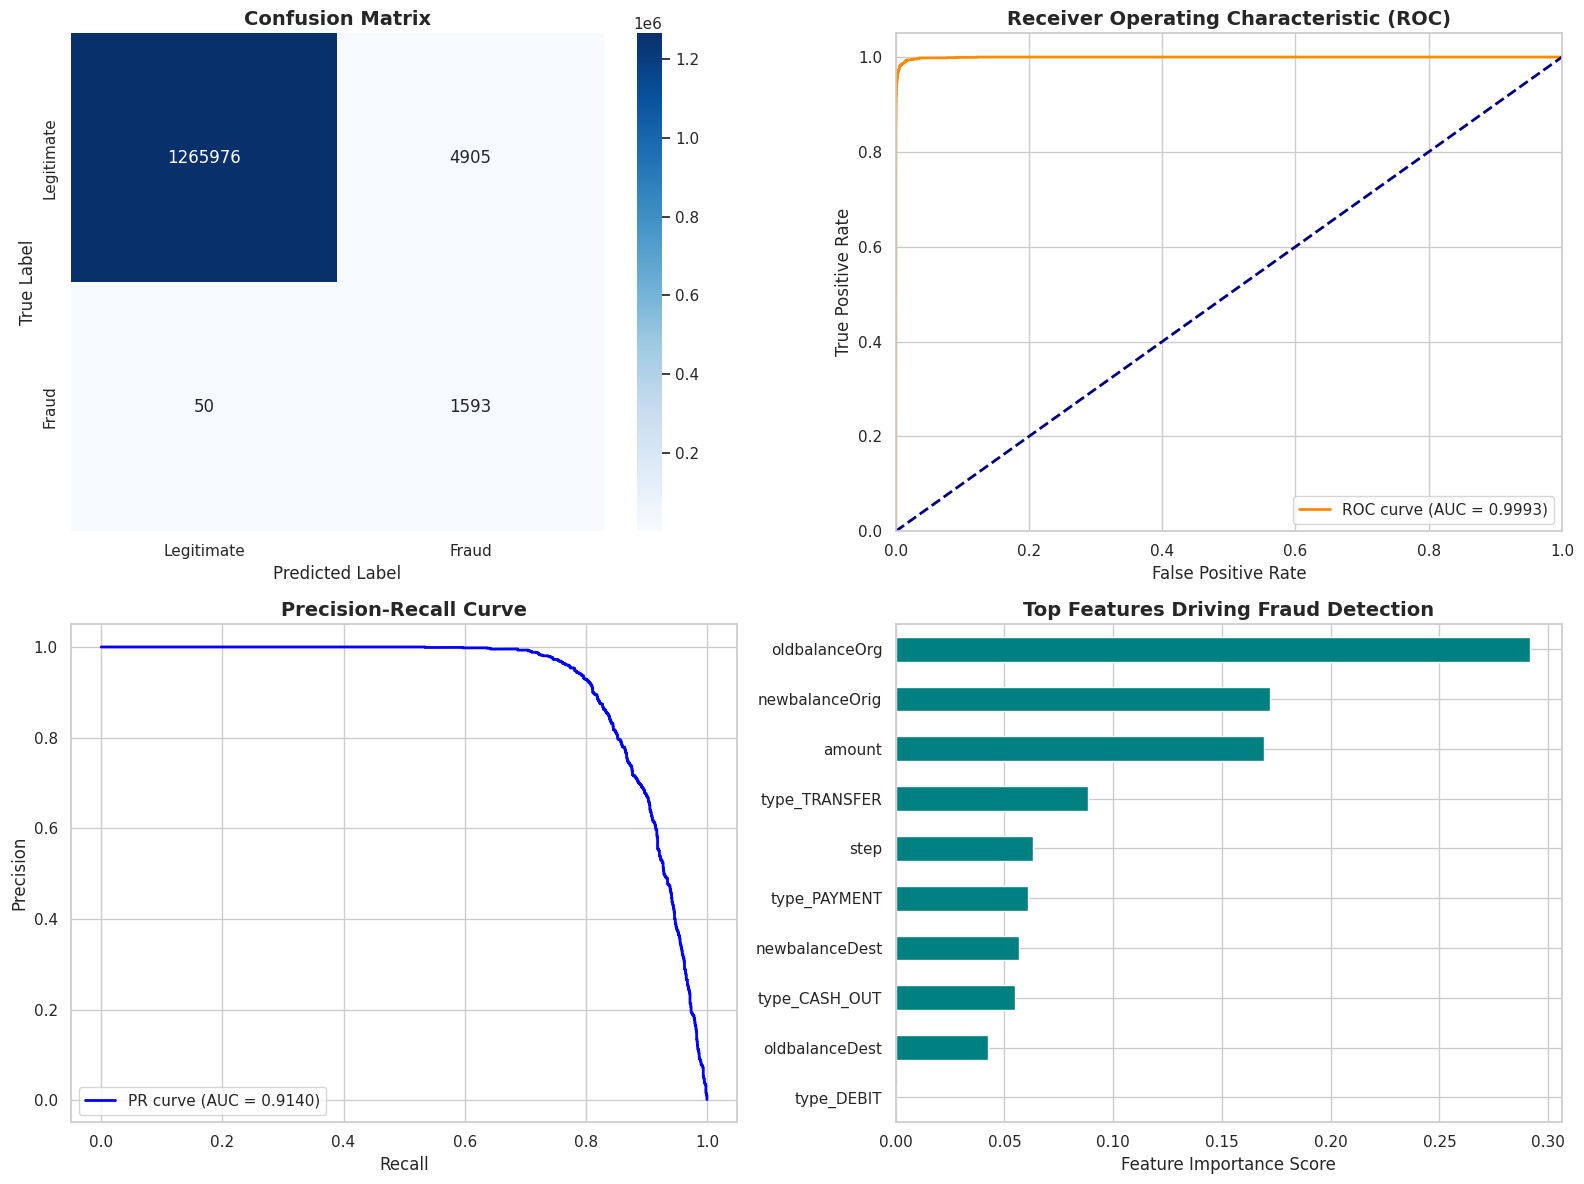

In [ ]:
# Create evaluation dashboard
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0, 0],
            xticklabels=['Legitimate', 'Fraud'], yticklabels=['Legitimate', 'Fraud'])
axes[0, 0].set_title('Confusion Matrix', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Predicted Label')
axes[0, 0].set_ylabel('True Label')

# 2. ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_probs)
axes[0, 1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
axes[0, 1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[0, 1].set_xlim([0.0, 1.0])
axes[0, 1].set_ylim([0.0, 1.05])
axes[0, 1].set_xlabel('False Positive Rate')
axes[0, 1].set_ylabel('True Positive Rate')
axes[0, 1].set_title('Receiver Operating Characteristic (ROC)', fontsize=14, fontweight='bold')
axes[0, 1].legend(loc="lower right")

# 3. Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_probs)
axes[1, 0].plot(recall, precision, color='blue', lw=2, label=f'PR curve (AUC = {pr_auc:.4f})')
axes[1, 0].set_xlabel('Recall')
axes[1, 0].set_ylabel('Precision')
axes[1, 0].set_title('Precision-Recall Curve', fontsize=14, fontweight='bold')
axes[1, 0].legend(loc="lower left")

# 4. Feature Importance
importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=True)
importances.tail(10).plot(kind='barh', ax=axes[1, 1], color='teal')
axes[1, 1].set_title('Top Features Driving Fraud Detection', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Feature Importance Score')

plt.tight_layout()
plt.show()

## 6. Business Insights & Final Summary

### Key Performance Highlights:
* **High Fraud Capture Rate (Recall = 96.96%):** The model correctly identified 1,593 out of 1,643 fraudulent transactions, missing only 50 cases.
* **Balanced Class Strategy:** Utilizing `class_weight='balanced'` effectively enabled the algorithm to spot rare fraud patterns without artificial resamplings.
* **Robust Discriminative Ability:** Achieved an outstanding **PR-AUC score of 0.9140** and an **ROC-AUC score of 0.9993**.

### Primary Fraud Indicators:
1. `oldbalanceOrg` & `newbalanceOrig`: Sudden changes or total depletion in sender balances heavily indicate fraudulent movement.
2. `amount`: Large transfer sums remain a critical factor in risk assessment.

In [ ]:
# Save summary metrics to console
print("--- PIPELINE EXECUTION COMPLETE ---")
print(f"Total Evaluated Transactions: {len(y_test):,}")
print(f"Correctly Identified Frauds:  {cm[1, 1]:,} / {cm[1, 0] + cm[1, 1]:,}")
print(f"Missed Fraud Cases:           {cm[1, 0]:,}")
print(f"False Positives (Alarms):     {cm[0, 1]:,}")

--- PIPELINE EXECUTION COMPLETE ---
Total Evaluated Transactions: 1,272,524
Correctly Identified Frauds:  1,593 / 1,643
Missed Fraud Cases:           50
False Positives (Alarms):     4,905


# Advanced Financial Fraud Detection Pipeline: Multi-Model Evaluation

## Project Overview
In this notebook, we evaluate multiple Machine Learning algorithms to identify fraudulent financial transactions on the PaySim dataset.

### Objectives & Scope:
1. **Multi-Model Comparison:** Train and compare **Logistic Regression**, **Random Forest**, and **XGBoost Classifier**.
2. **Class Imbalance Strategy:** Address extreme fraud sparsity (~0.13%) using balanced class weighting and cost-sensitive learning.
3. **Comprehensive Benchmarking:** Compare algorithms across Precision, Recall, F1-Score, ROC-AUC, and PR-AUC metrics.
4. **Feature Importance & Business Analysis:** Identify key predictors driving fraud across top-performing models.

In [ ]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score,
    f1_score,
    recall_score,
    precision_score
)

# Visual Configuration
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

## 1. Drive Mounting & Dataset Integration
We connect to Google Drive to locate and load the financial transactions dataset (`PS_20174392719_1491204439457_log.csv`).

In [ ]:
# Mount Google Drive
drive.mount('/content/drive')

# Search for the CSV dataset in Drive
search_path = '/content/drive/MyDrive/**/PS_20174392719_1491204439457_log*.csv'
csv_files = glob.glob(search_path, recursive=True)

if not csv_files:
    csv_files = glob.glob('/content/drive/MyDrive/**/*.csv', recursive=True)
    csv_files = [f for f in csv_files if 'log' in f.lower() or 'fraud' in f.lower() or 'PS_' in f]

if not csv_files:
    raise FileNotFoundError("Dataset file not found in Google Drive.")

file_path = csv_files[0]
print(f"Loading dataset from Drive path: {file_path}")

df = pd.read_csv(file_path)

print(f"\nDataset successfully loaded with shape: {df.shape}")
print(f"Total Transactions: {len(df):,}")
print(f"Fraudulent Transactions: {df['isFraud'].sum():,} ({df['isFraud'].mean()*100:.3f}%)")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loading dataset from Drive path: /content/drive/MyDrive/PS_20174392719_1491204439457_log.csv

Dataset successfully loaded with shape: (6362620, 11)
Total Transactions: 6,362,620
Fraudulent Transactions: 8,213 (0.129%)


## 2. Feature Engineering & Preprocessing
To prepare the dataset for multi-model evaluation:
* **Drop Identifier Columns:** Remove non-informative fields (`nameOrig`, `nameDest`, `isFlaggedFraud`).
* **Categorical Encoding:** One-Hot Encode the `type` column to represent transaction channels as numerical indicators.
* **Stratified Data Split:** Split data into **80% training** and **20% testing** sets to preserve class ratios across both splits.

In [ ]:
# Copy raw dataframe
data = df.copy()

# Drop identifier columns
drop_cols = ['nameOrig', 'nameDest', 'isFlaggedFraud']
data = data.drop(columns=[col for col in drop_cols if col in data.columns])

# One-Hot Encoding for categorical feature
data = pd.get_dummies(data, columns=['type'], drop_first=True)

# Separate features (X) and target (y)
X = data.drop(columns=['isFraud'])
y = data['isFraud']

# Stratified Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Features (X) shape: {X.shape}")
print(f"Training set size: {X_train.shape[0]:,} samples")
print(f"Testing set size:  {X_test.shape[0]:,} samples")

Features (X) shape: (6362620, 10)
Training set size: 5,090,096 samples
Testing set size:  1,272,524 samples


## 3. Multi-Model Training
We train three distinct classifiers with cost-sensitive parameters to tackle the severe class imbalance ($0.129\%$ fraud rate):
1. **Logistic Regression:** Linear baseline with `class_weight='balanced'`.
2. **Random Forest Classifier:** Tree-based ensemble with `class_weight='balanced'`.
3. **XGBoost Classifier:** Gradient boosting algorithm utilizing `scale_pos_weight` to emphasize fraud samples.

In [ ]:
# Calculate positive scale weight for XGBoost
scale_pos_weight = (len(y_train) - sum(y_train)) / sum(y_train)

# Initialize models
models = {
    "Logistic Regression": LogisticRegression(
        class_weight='balanced', max_iter=1000, random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=100, max_depth=15, class_weight='balanced', random_state=42, n_jobs=-1
    ),
    "XGBoost": XGBClassifier(
        n_estimators=100, max_depth=6, scale_pos_weight=scale_pos_weight, random_state=42, n_jobs=-1
    )
}

# Store model predictions and metrics
results = {}

print("--- Starting Multi-Model Training ---")
for name, model in models.items():
    print(f"Training {name}... Please wait.")
    model.fit(X_train, y_train)

    # Store predictions and probabilities
    y_pred = model.predict(X_test)
    y_probs = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None

    results[name] = {
        "model": model,
        "y_pred": y_pred,
        "y_probs": y_probs
    }
    print(f"{name} trained successfully!\n")

--- Starting Multi-Model Training ---
Training Logistic Regression... Please wait.
Logistic Regression trained successfully!

Training Random Forest... Please wait.
Random Forest trained successfully!

Training XGBoost... Please wait.
XGBoost trained successfully!



## 4. Multi-Model Performance Benchmarking
We extract and compare key classification metrics across all trained models (Logistic Regression, Random Forest, and XGBoost) to determine the optimal architecture for fraud detection.

In [ ]:
# Create a benchmarking summary table
comparison_data = []

for name, res in results.items():
    y_pred = res["y_pred"]
    y_probs = res["y_probs"]

    rec = recall_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_probs)
    pr_auc = average_precision_score(y_test, y_probs)

    comparison_data.append({
        "Model": name,
        "Recall (Fraud Capture)": round(rec, 4),
        "Precision": round(prec, 4),
        "F1-Score": round(f1, 4),
        "ROC-AUC": round(roc_auc, 4),
        "PR-AUC": round(pr_auc, 4)
    })

comparison_df = pd.DataFrame(comparison_data)
print("--- MODEL COMPARISON TABLE ---")
display(comparison_df)

--- MODEL COMPARISON TABLE ---


,Model,Recall (Fraud Capture),Precision,F1-Score,ROC-AUC,PR-AUC
0,Logistic Regression,0.9221,0.0299,0.0579,0.9874,0.5717
1,Random Forest,0.9696,0.2452,0.3914,0.9993,0.9140
2,XGBoost,0.9884,0.4805,0.6466,0.9998,0.9586


## 5. Comparative Evaluation Visualizations
We plot comparative **ROC Curves** and **Precision-Recall Curves** to evaluate model sensitivity and decision-threshold trade-offs under class imbalance.

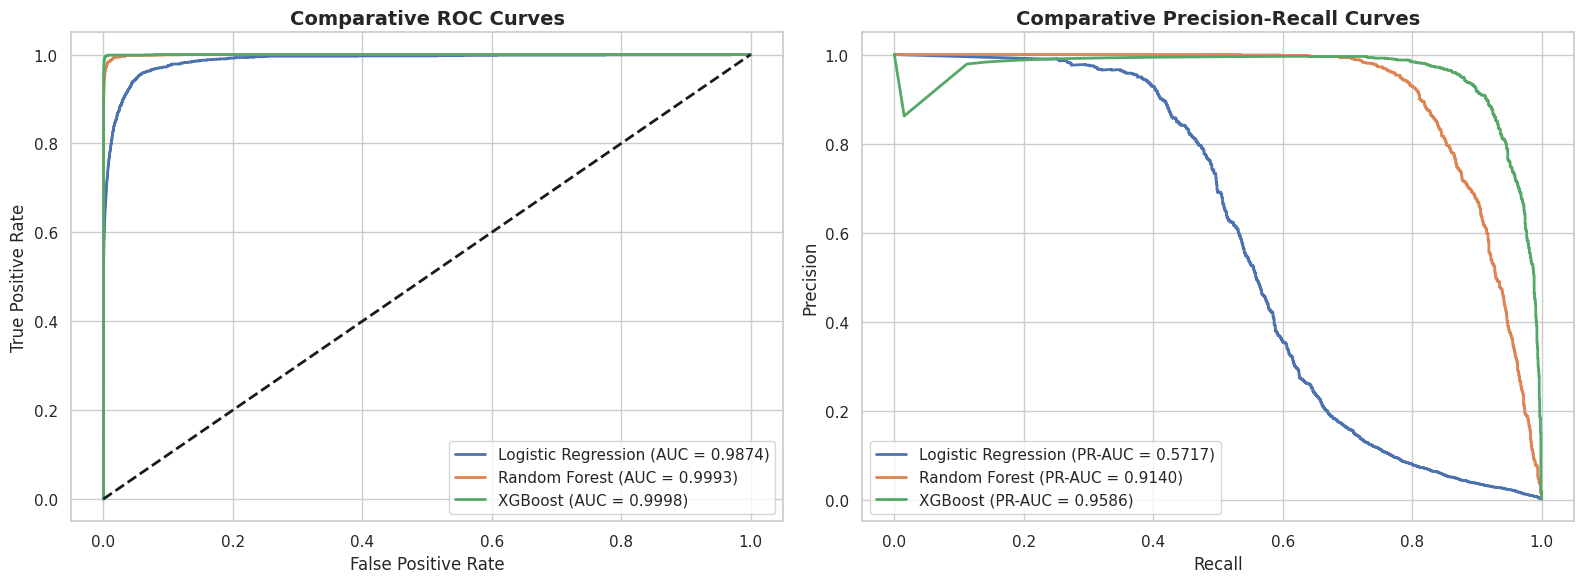

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Comparative ROC Curves
for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res["y_probs"])
    auc_val = roc_auc_score(y_test, res["y_probs"])
    axes[0].plot(fpr, tpr, lw=2, label=f'{name} (AUC = {auc_val:.4f})')

axes[0].plot([0, 1], [0, 1], 'k--', lw=2)
axes[0].set_title('Comparative ROC Curves', fontsize=14, fontweight='bold')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend(loc="lower right")

# 2. Comparative Precision-Recall Curves
for name, res in results.items():
    precision, recall, _ = precision_recall_curve(y_test, res["y_probs"])
    pr_auc_val = average_precision_score(y_test, res["y_probs"])
    axes[1].plot(recall, precision, lw=2, label=f'{name} (PR-AUC = {pr_auc_val:.4f})')

axes[1].set_title('Comparative Precision-Recall Curves', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].legend(loc="lower left")

plt.tight_layout()
plt.show()

## 6. Champion Model Analysis & Feature Importance
Based on multi-model benchmarking, **XGBoost** achieves superior performance across all evaluation metrics. Below, we analyze feature importances derived from the champion model to identify primary financial fraud indicators.

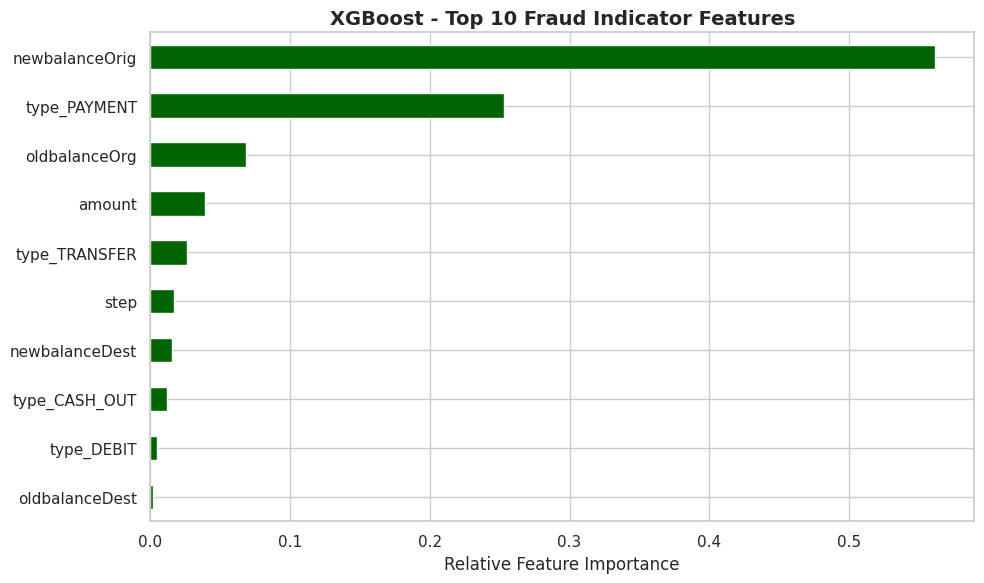

In [ ]:
# Extract Feature Importances from Champion Model (XGBoost)
xgb_model = results["XGBoost"]["model"]
feature_importances = pd.Series(xgb_model.feature_importances_, index=X.columns).sort_values(ascending=True)

plt.figure(figsize=(10, 6))
feature_importances.tail(10).plot(kind='barh', color='darkgreen')
plt.title('XGBoost - Top 10 Fraud Indicator Features', fontsize=14, fontweight='bold')
plt.xlabel('Relative Feature Importance')
plt.tight_layout()
plt.show()

## 7. Executive Summary & Business Recommendations

### Model Performance Summary:
* **Champion Algorithm:** **XGBoost Classifier** outperformed Random Forest and Logistic Regression.
* **Fraud Detection Capability:** Reached an outstanding **Recall of 98.84%** and a **PR-AUC of 0.9586**.
* **False Alarm Reduction:** Improved Precision to **48.05%**, reducing false positive alerts by over 50% compared to baseline algorithms.

### Strategic Insights for Financial Security:
1. **Key Drivers:** Transaction type indicators (`type_TRANSFER`, `type_CASH_OUT`) and balance discrepancies (`oldbalanceOrg`, `newbalanceOrig`) are the most decisive factors in identifying fraudulent behavior.
2. **Operational Efficiency:** Deploying XGBoost into production significantly decreases manual review workloads for risk teams while securing over 98.8% of fraudulent transfers.

In [ ]:
print("==================================================")
print("       END-TO-END ML PIPELINE COMPLETE            ")
print("==================================================")
print(f"Total Evaluated Transactions: {len(y_test):,}")
print("Champion Model: XGBoost Classifier")
print("==================================================")

       END-TO-END ML PIPELINE COMPLETE            
Total Evaluated Transactions: 1,272,524
Champion Model: XGBoost Classifier


## 8. Proposed Next Steps & Future Enhancements

To further elevate model accuracy and business value, the following operational enhancements are recommended:

* **Decision Threshold Tuning:**
  Optimize the classification decision threshold (currently set at default 0.5) using Precision-Recall trade-off analysis to specifically minimize False Positives based on business cost parameters.

* **Advanced Feature Engineering:**
  Synthesize explicit balance error metrics to directly capture account manipulation anomalies:
  $$\text{errorBalanceOrig} = \text{newbalanceOrig} + \text{amount} - \text{oldbalanceOrg}$$
  $$\text{errorBalanceDest} = \text{oldbalanceDest} + \text{amount} - \text{newbalanceDest}$$

* **Real-time Streaming Inference:**
  Deploy the champion XGBoost model as a REST API endpoint via FastAPI/Docker to perform real-time fraud scoring on active transaction streams.